## 2. Analysis Phase contd.

### 2. Subscriber Data Analysis

In [1]:
import pandas as pd
import matplotlib as plt

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
lio_subs = pd.read_csv('LioCinema CSV files/subscribers.csv')
jotstar_subs = pd.read_csv('Jotstar CSV files/subscribers.csv')

In [4]:
lio_subs.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaN,NaN,NaN
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaN,NaN,NaN
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaN,2024-04-23,Free
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaN,2024-11-07,Free


In [5]:
jotstar_subs.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaN,NaN,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaN,NaN,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaN,NaN,NaN
3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaN,NaN,NaN
4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaN,NaN,NaN


In [6]:
# Add a identifer
lio_subs['platform'] = "LioCinema"
jotstar_subs['platform'] = "Jotstar"

In [7]:
# combine the datasets
combined_subscribers_df = pd.concat([lio_subs, jotstar_subs], ignore_index=True)

In [8]:
combined_subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,platform
0,UIDLC00000bea68a,25-34,Tier 3,2024-10-24,Free,NaN,NaN,NaN,LioCinema
1,UIDLC00009202848,18-24,Tier 1,2024-09-18,Basic,NaN,NaN,NaN,LioCinema
2,UIDLC0001086afc3,35-44,Tier 2,2024-03-23,Premium,NaN,2024-04-23,Free,LioCinema
3,UIDLC000186abd93,18-24,Tier 3,2024-09-07,Free,2024-10-23,NaN,NaN,LioCinema
4,UIDLC0002189b09f,18-24,Tier 2,2024-10-07,Premium,NaN,2024-11-07,Free,LioCinema


In [9]:
combined_subscribers_df.dtypes

user_id                  object
age_group                object
city_tier                object
subscription_date        object
subscription_plan        object
last_active_date         object
plan_change_date         object
new_subscription_plan    object
platform                 object
dtype: object

In [10]:
# convert the subscription_date Column to datetime
combined_subscribers_df['subscription_date'] = pd.to_datetime(combined_subscribers_df['subscription_date'])


In [11]:
combined_subscribers_df.dtypes

user_id                          object
age_group                        object
city_tier                        object
subscription_date        datetime64[ns]
subscription_plan                object
last_active_date                 object
plan_change_date                 object
new_subscription_plan            object
platform                         object
dtype: object

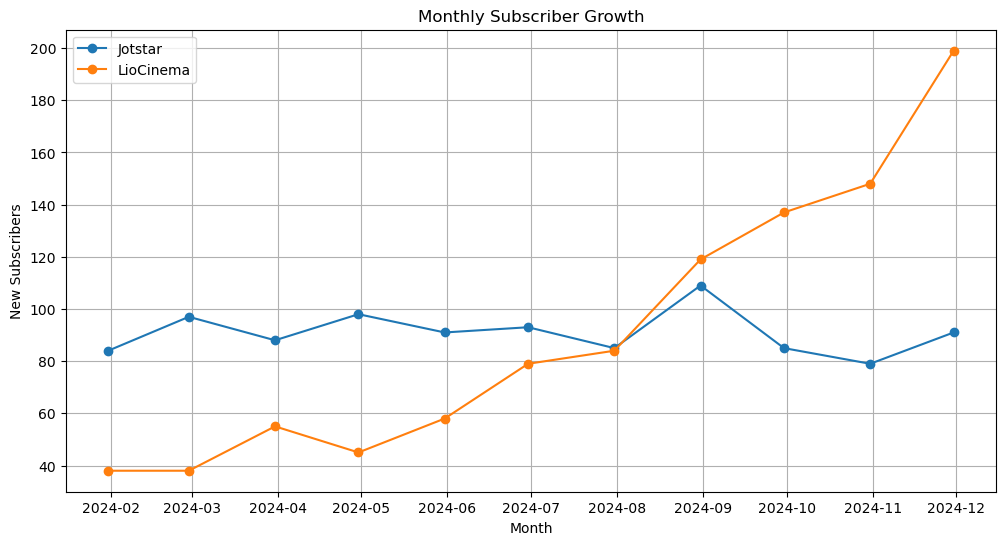

In [12]:
# 2.1 Monthly Subscribers Growth
plt.figure (figsize = (12,6))

for platform, df in combined_subscribers_df.groupby('platform'):
    monthly = df.set_index ('subscription_date').resample('M').size()
    #print (monthly)
    plt.plot (monthly.index, monthly.values, label = platform, marker = 'o')

plt.title ("Monthly Subscriber Growth")
plt.xlabel('Month')
plt.ylabel ('New Subscribers')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
combined_subscribers_df['age_group'].nunique()


4

<Axes: xlabel='platform'>

<Figure size 1600x600 with 0 Axes>

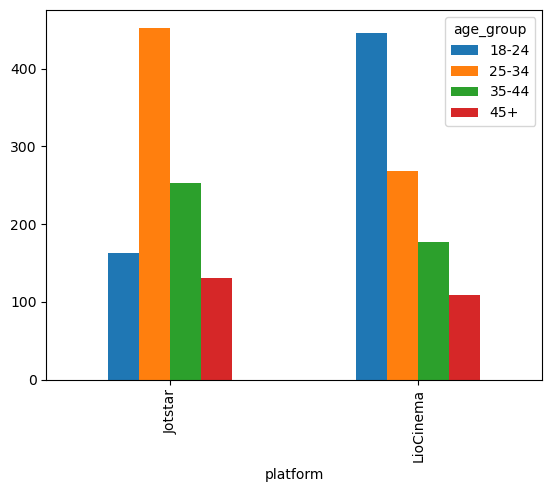

In [14]:
# 2.2 No of Subscribers by By Age Group for each Platform
age_dist = combined_subscribers_df.groupby(['platform', 'age_group']).size().unstack()
plt.figure (figsize = (16,6))
age_dist.plot (kind = "bar")

<Axes: xlabel='platform'>

<Figure size 1600x600 with 0 Axes>

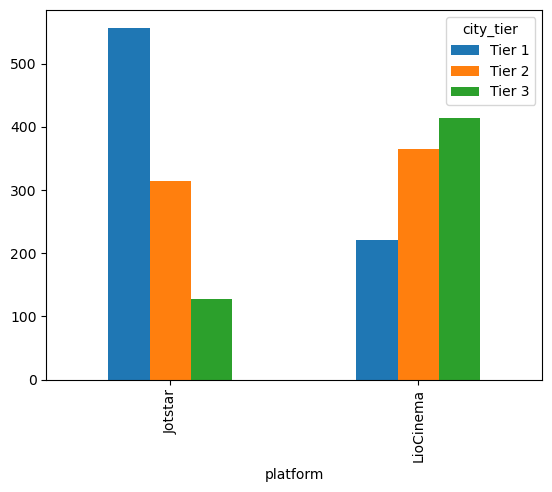

In [15]:
# # 2.3 No of Subscribers by By Age Group for each Platform
age_dist = combined_subscribers_df.groupby(['platform', 'city_tier']).size().unstack()
plt.figure (figsize = (16,6))
age_dist.plot (kind = "bar")

<Axes: xlabel='platform'>

<Figure size 1600x600 with 0 Axes>

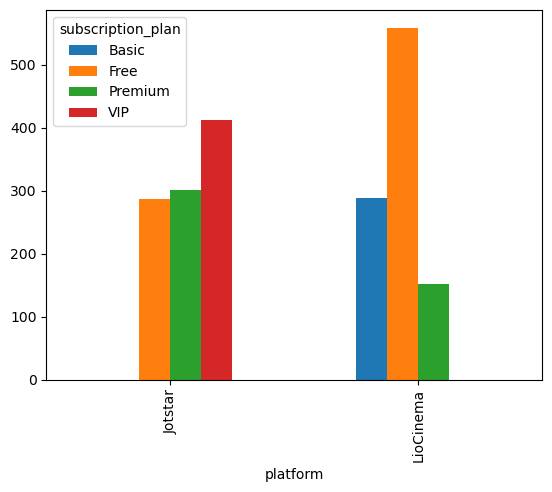

In [ ]:
# 2.4 No of Subscribers by By Subscription Plan for each Platform
age_dist = combined_subscribers_df.groupby(['platform', 'subscription_plan']).size().unstack()
plt.figure (figsize = (16,6))
age_dist.plot (kind = "bar")